In [1]:
# Prueba del kernel
import pandas as pd
import mysql.connector

print("Kernel listo")

Kernel listo


In [2]:
# Conexion a la base de datos
from getpass import getpass

conexion = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",
    password=getpass("Contraseña de MySQL: "),
    database="classicmodels"
)

# Consulta de prueba
cursor = conexion.cursor()
cursor.execute("SHOW TABLES")
tablas = pd.DataFrame(cursor.fetchall(), columns=["tabla"])
cursor.close()

tablas

,tabla
0,customers
1,employees
2,offices
3,orderdetails
4,orders
5,payments
6,productlines
7,products


In [3]:
# Funcion para traer una consulta como DataFrame
def consultar(sql):
    cursor = conexion.cursor()
    cursor.execute(sql)
    columnas = [c[0] for c in cursor.description]
    datos = pd.DataFrame(cursor.fetchall(), columns=columnas)
    cursor.close()
    return datos

# Cargar las tablas principales
customers = consultar("SELECT * FROM customers")
orders = consultar("SELECT * FROM orders")
orderdetails = consultar("SELECT * FROM orderdetails")
products = consultar("SELECT * FROM products")
payments = consultar("SELECT * FROM payments")
employees = consultar("SELECT * FROM employees")
offices = consultar("SELECT * FROM offices")

# Cantidad de filas y columnas por tabla
for nombre, df in [("customers", customers), ("orders", orders),
                   ("orderdetails", orderdetails), ("products", products),
                   ("payments", payments), ("employees", employees),
                   ("offices", offices)]:
    print(nombre, df.shape)

# Convertir columnas Decimal a numero
from decimal import Decimal

for df in [customers, orders, orderdetails, products, payments, employees, offices]:
    for col in df.columns:
        if df[col].map(lambda v: isinstance(v, Decimal)).any():
            df[col] = df[col].astype(float)

print(products.dtypes)

customers (122, 13)
orders (326, 7)
orderdetails (2996, 5)
products (110, 9)
payments (273, 4)
employees (23, 8)
offices (7, 9)
productCode               str
productName               str
productLine               str
productScale              str
productVendor             str
productDescription        str
quantityInStock         int64
buyPrice              float64
MSRP                  float64
dtype: object


In [4]:
# Librerias de graficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Gráfico 1: Límite de crédito de los clientes (creditLimit)

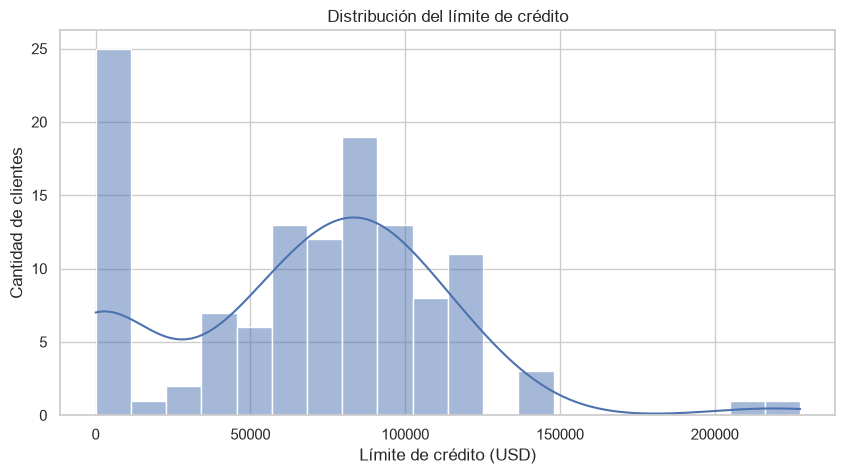

count       122.000000
mean      67659.016393
std       45043.370751
min           0.000000
25%       42175.000000
50%       76700.000000
75%       95075.000000
max      227600.000000
Name: creditLimit, dtype: float64

In [5]:
# Distribucion del limite de credito
sns.histplot(customers["creditLimit"], bins=20, kde=True)
plt.title("Distribución del límite de crédito")
plt.xlabel("Límite de crédito (USD)")
plt.ylabel("Cantidad de clientes")
plt.show()

customers["creditLimit"].describe()

In [6]:
# Clientes sin credito
sin_credito = (customers["creditLimit"] == 0).sum()
print("Clientes con crédito 0:", sin_credito)
print("Porcentaje:", round(sin_credito / len(customers) * 100, 1), "%")

Clientes con crédito 0: 24
Porcentaje: 19.7 %


**Interpretación:** La mayoría de los clientes tiene un límite de crédito entre 42.175 y 95.075 USD, con una mediana de 76.700 USD. Llama la atención la barra en 0: 24 clientes (19,7 %) no tienen crédito aprobado. Estos ceros bajan el promedio a 67.659 USD, por eso la mediana representa mejor al cliente típico. También hay unos pocos clientes con créditos muy altos, cerca de 227.600 USD, que son casos fuera de lo común. Para el negocio, los clientes sin crédito podrían ser clientes nuevos o de riesgo, y valdría la pena revisar si se les puede ofrecer crédito para aumentar las ventas.

## Gráfico 2: País de los clientes (country)

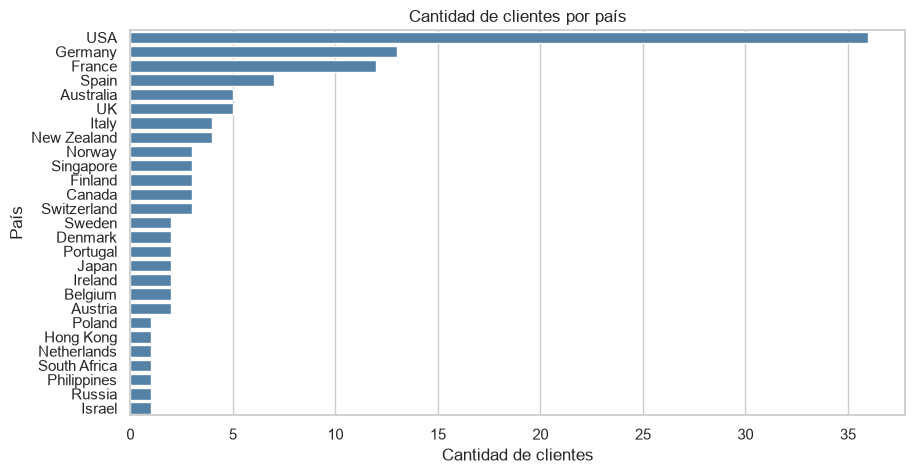

Total de países: 27


country
USA          36
Germany      13
France       12
Spain         7
Australia     5
Name: count, dtype: int64

In [7]:
# Cantidad de clientes por pais
conteo_pais = customers["country"].str.strip().value_counts()

sns.barplot(x=conteo_pais.values, y=conteo_pais.index, color="steelblue")
plt.title("Cantidad de clientes por país")
plt.xlabel("Cantidad de clientes")
plt.ylabel("País")
plt.show()

print("Total de países:", conteo_pais.size)
conteo_pais.head(5)

**Interpretación:** Los clientes están en 27 países, pero muy concentrados. Estados Unidos es el mercado principal con 36 clientes (cerca del 30 %), seguido de Alemania (13) y Francia (12). Entre estos tres países suman 61 clientes, es decir, la mitad del total. Europa también tiene mucho peso, con varios países en la lista. En cambio, países como Polonia, Rusia o Israel solo tienen 1 o 2 clientes. Durante la revisión encontramos que "Norway" aparecía dos veces por espacios de más en el nombre, y lo corregimos con `str.strip()`. Para el negocio, depender tanto de Estados Unidos es un riesgo, y los países con pocos clientes podrían ser una oportunidad para crecer.

## Gráfico 3: Precio de compra de los productos (buyPrice)

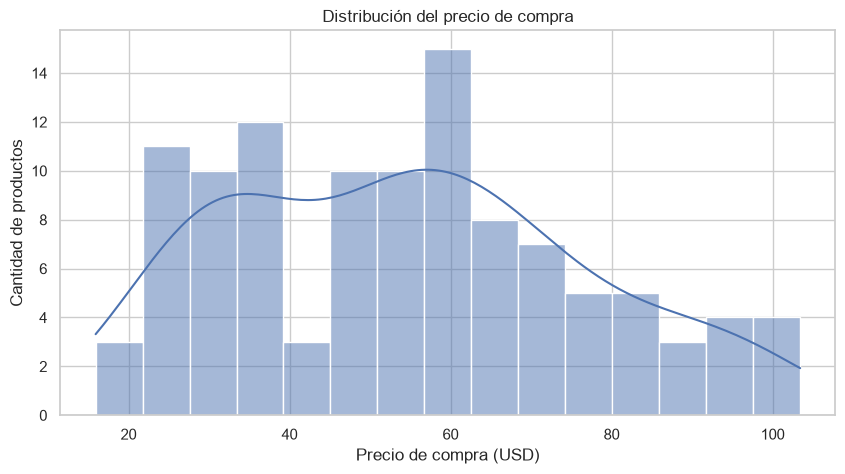

count    110.000000
mean      54.395182
std       22.051130
min       15.910000
25%       34.180000
50%       53.915000
75%       68.675000
max      103.420000
Name: buyPrice, dtype: float64

In [8]:
# Distribucion del precio de compra
sns.histplot(products["buyPrice"], bins=15, kde=True)
plt.title("Distribución del precio de compra")
plt.xlabel("Precio de compra (USD)")
plt.ylabel("Cantidad de productos")
plt.show()

products["buyPrice"].describe()

**Interpretación:** Los 110 productos tienen un precio de compra entre 15,91 y 103,42 USD. El promedio (54,40 USD) y la mediana (53,92 USD) son casi iguales, lo que indica que los precios están bastante equilibrados y no hay valores extremos. La mitad de los productos cuesta entre 34,18 y 68,68 USD, y el grupo más grande está cerca de los 60 USD. Hay pocos productos caros (más de 80 USD), por eso la gráfica baja hacia la derecha. Para el negocio, esto muestra que el catálogo se enfoca en productos de precio medio, y los productos más caros podrían revisarse para saber si dejan más ganancia.

## Gráfico 4: Unidades en inventario (quantityInStock)

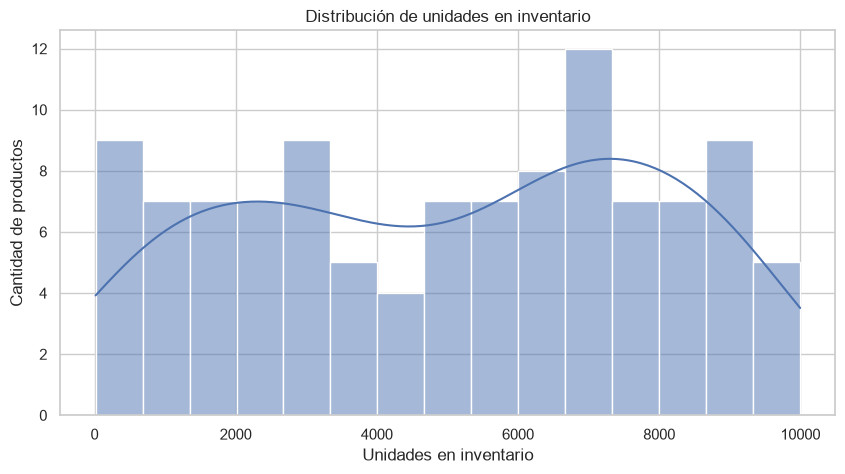

Productos con menos de 1000 unidades: 12


count     110.000000
mean     5046.645455
std      2939.263668
min        15.000000
25%      2419.000000
50%      5437.500000
75%      7599.750000
max      9997.000000
Name: quantityInStock, dtype: float64

In [9]:
# Distribucion del inventario
sns.histplot(products["quantityInStock"], bins=15, kde=True)
plt.title("Distribución de unidades en inventario")
plt.xlabel("Unidades en inventario")
plt.ylabel("Cantidad de productos")
plt.show()

# Productos con poco inventario
poco_stock = (products["quantityInStock"] < 1000).sum()
print("Productos con menos de 1000 unidades:", poco_stock)

products["quantityInStock"].describe()

**Interpretación:** El inventario de los 110 productos va de 15 a 9.997 unidades. El promedio (5.047) y la mediana (5.438) están cerca, y las barras tienen alturas parecidas en todo el rango, lo que muestra que el inventario está repartido de forma bastante pareja entre los productos. La mitad de los productos tiene entre 2.419 y 7.600 unidades. Sin embargo, 12 productos (cerca del 11 %) tienen menos de 1.000 unidades, y uno tiene apenas 15. Para el negocio, esos productos con poco inventario podrían agotarse pronto, por lo que conviene revisar si se venden mucho y reabastecerlos a tiempo.

## Gráfico 5: Línea de producto (productLine)

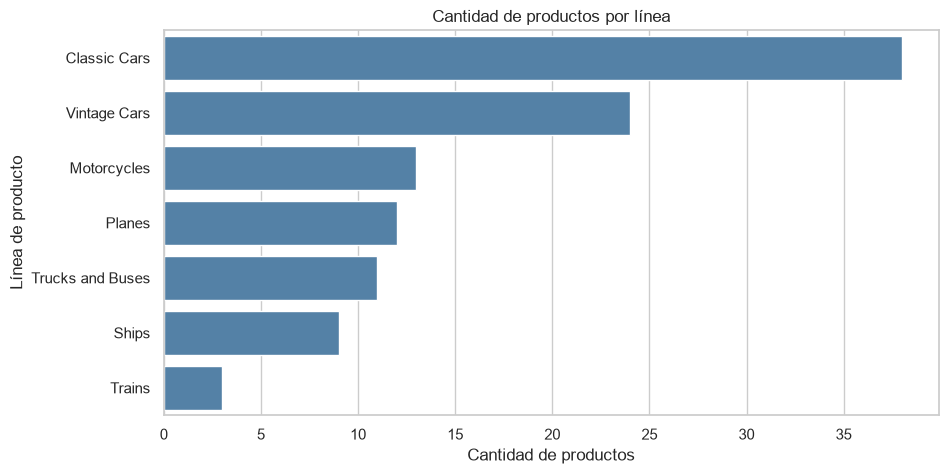

Total de líneas: 7


productLine
Classic Cars        38
Vintage Cars        24
Motorcycles         13
Planes              12
Trucks and Buses    11
Ships                9
Trains               3
Name: count, dtype: int64

In [10]:
# Cantidad de productos por linea
conteo_linea = products["productLine"].str.strip().value_counts()

sns.barplot(x=conteo_linea.values, y=conteo_linea.index, color="steelblue")
plt.title("Cantidad de productos por línea")
plt.xlabel("Cantidad de productos")
plt.ylabel("Línea de producto")
plt.show()

print("Total de líneas:", conteo_linea.size)
conteo_linea

**Interpretación:** Los 110 productos se dividen en 7 líneas. La más grande es Classic Cars con 38 productos (cerca del 35 %), seguida de Vintage Cars con 24. Entre las dos suman 62 productos, más de la mitad del catálogo, lo que muestra que la empresa se enfoca en carros a escala. Después vienen Motorcycles (13), Planes (12), Trucks and Buses (11) y Ships (9). Trains es la línea más pequeña, con solo 3 productos. Para el negocio, conviene revisar si las líneas con menos productos venden poco por falta de variedad, y si vale la pena ampliarlas o enfocarse en los carros, que son el fuerte.

## Gráfico 6: Escala de los productos (productScale)

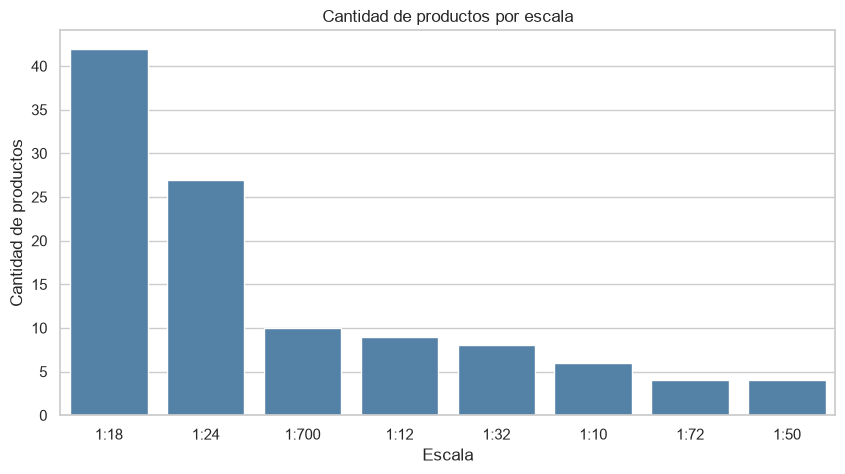

Total de escalas: 8


productScale
1:18     42
1:24     27
1:700    10
1:12      9
1:32      8
1:10      6
1:72      4
1:50      4
Name: count, dtype: int64

In [11]:
# Cantidad de productos por escala
conteo_escala = products["productScale"].str.strip().value_counts()

sns.barplot(x=conteo_escala.index, y=conteo_escala.values, color="steelblue")
plt.title("Cantidad de productos por escala")
plt.xlabel("Escala")
plt.ylabel("Cantidad de productos")
plt.show()

print("Total de escalas:", conteo_escala.size)
conteo_escala

**Interpretación:** Los productos se fabrican en 8 escalas distintas. La más común es 1:18, con 42 productos (cerca del 38 %), seguida de 1:24 con 27. Entre las dos suman 69 productos, casi dos de cada tres. Esto tiene sentido con el Gráfico 5, porque son escalas muy usadas en carros a escala, que son la línea principal. Las escalas menos comunes son 1:72 y 1:50, con 4 productos cada una. Hay que tener en cuenta que entre más grande el segundo número, más pequeño es el modelo (1:10 es grande y 1:700 es muy pequeño). Para el negocio, la empresa se enfoca en modelos de tamaño mediano a grande, y las escalas poco usadas podrían ser una oportunidad para clientes coleccionistas.

## Gráfico 7: Estado de los pedidos (status)

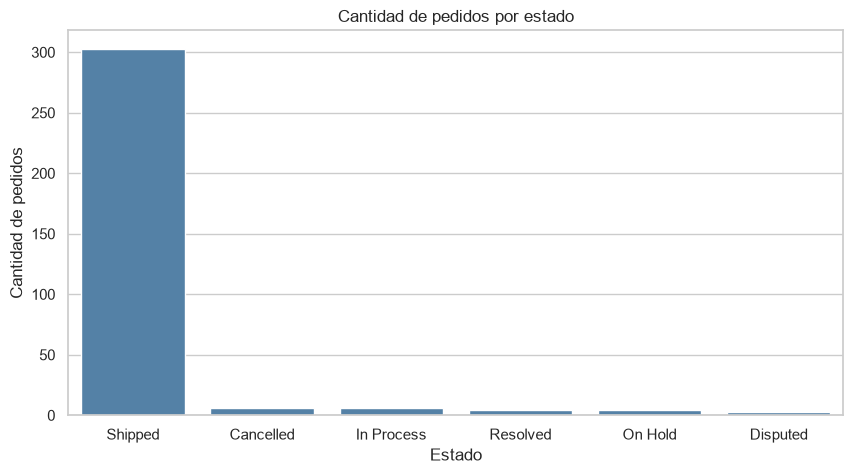

,pedidos,porcentaje
status,,
Shipped,303,92.9
Cancelled,6,1.8
In Process,6,1.8
Resolved,4,1.2
On Hold,4,1.2
Disputed,3,0.9


In [12]:
# Cantidad de pedidos por estado
conteo_estado = orders["status"].str.strip().value_counts()

sns.barplot(x=conteo_estado.index, y=conteo_estado.values, color="steelblue")
plt.title("Cantidad de pedidos por estado")
plt.xlabel("Estado")
plt.ylabel("Cantidad de pedidos")
plt.show()

# Porcentaje por estado
porcentaje = (conteo_estado / conteo_estado.sum() * 100).round(1)
pd.DataFrame({"pedidos": conteo_estado, "porcentaje": porcentaje})

**Interpretación:** De los 326 pedidos, 303 fueron enviados (92,9 %), lo que muestra que la empresa completa la gran mayoría de sus ventas. Los demás estados son pocos: 6 cancelados (1,8 %), 6 en proceso (1,8 %), 4 resueltos (1,2 %), 4 retenidos (1,2 %) y 3 en disputa (0,9 %). Como la barra de "Shipped" es tan alta, los otros estados casi no se ven en el gráfico, por eso la tabla de porcentajes ayuda a leerlos. Si sumamos cancelados, retenidos y en disputa, 13 pedidos (4 %) tuvieron algún problema. Para el negocio, es un porcentaje bajo, pero vale la pena revisar las causas de esos casos para evitar perder clientes o dinero.

## Gráfico 8: Pedidos por mes (orderDate)

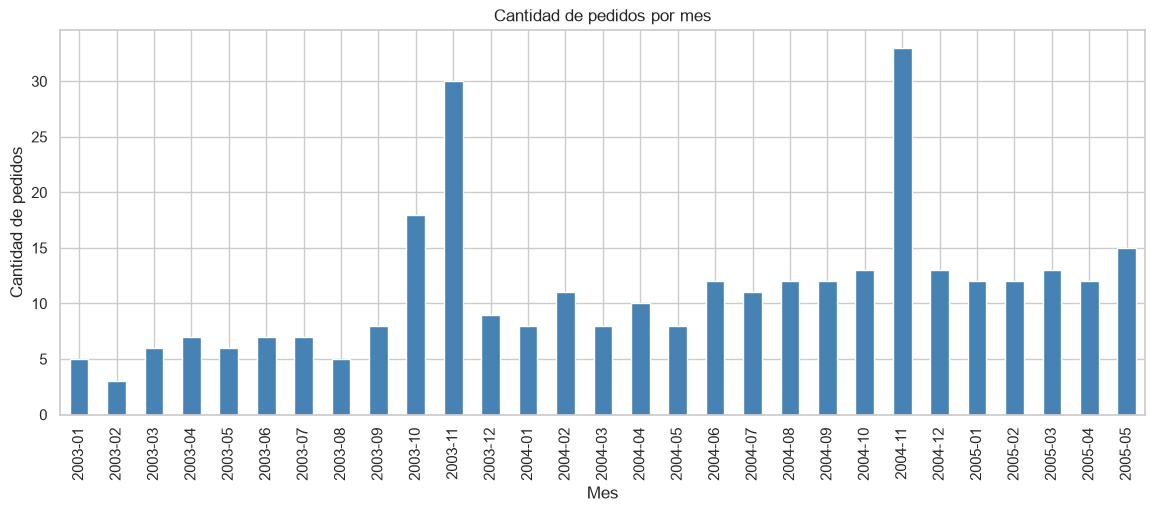

Primer pedido: 2003-01-06
Último pedido: 2005-05-31

Meses con más pedidos:
orderDate
2004-11    33
2003-11    30
2003-10    18
Freq: M, Name: count, dtype: int64

Pedidos por año:


orderDate
2003    111
2004    151
2005     64
Name: count, dtype: int64

In [13]:
# Cantidad de pedidos por mes
fechas = pd.to_datetime(orders["orderDate"])
pedidos_mes = fechas.dt.to_period("M").value_counts().sort_index()

pedidos_mes.plot(kind="bar", color="steelblue", figsize=(14, 5))
plt.title("Cantidad de pedidos por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=90)
plt.show()

print("Primer pedido:", fechas.min().date())
print("Último pedido:", fechas.max().date())
print("\nMeses con más pedidos:")
print(pedidos_mes.sort_values(ascending=False).head(3))
print("\nPedidos por año:")
fechas.dt.year.value_counts().sort_index()

**Interpretación:** Los pedidos van del 6 de enero de 2003 al 31 de mayo de 2005. Hay que tener cuidado al comparar años, porque 2005 solo tiene datos de 5 meses. Entre los años completos, los pedidos crecieron de 111 en 2003 a 151 en 2004, cerca de un 36 % más. En 2005 hubo 64 pedidos en 5 meses, unos 12,8 por mes, un ritmo parecido al de 2004 (12,6 por mes). Lo que más llama la atención son los picos de noviembre: 30 pedidos en 2003 y 33 en 2004, los meses con más ventas. Como se repite cada año, parece un comportamiento de temporada, probablemente por las compras de fin de año. Para el negocio, conviene preparar inventario y personal antes de octubre y noviembre para atender ese aumento.

## Gráfico 9: Unidades pedidas por producto (quantityOrdered)

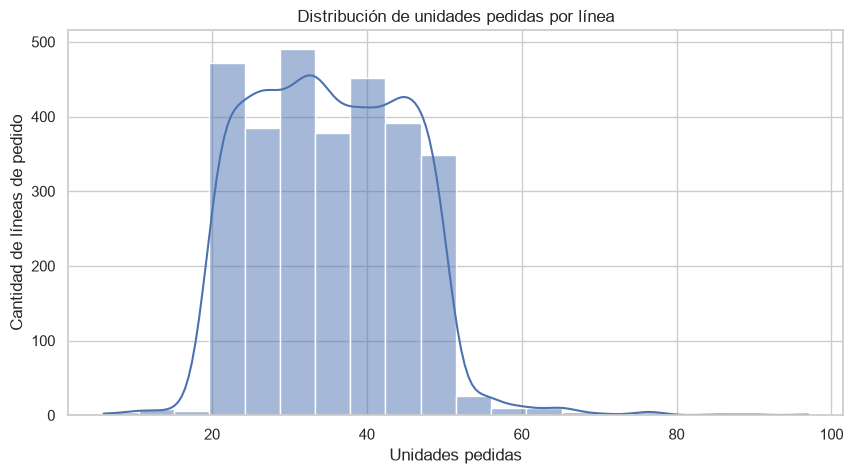

count    2996.000000
mean       35.218959
std         9.833885
min         6.000000
25%        27.000000
50%        35.000000
75%        43.000000
max        97.000000
Name: quantityOrdered, dtype: float64

In [14]:
# Distribucion de unidades pedidas
sns.histplot(orderdetails["quantityOrdered"], bins=20, kde=True)
plt.title("Distribución de unidades pedidas por línea")
plt.xlabel("Unidades pedidas")
plt.ylabel("Cantidad de líneas de pedido")
plt.show()

orderdetails["quantityOrdered"].describe()

**Interpretación:** En las 2.996 líneas de pedido se piden entre 6 y 97 unidades por producto. El promedio (35,2) y la mediana (35) son casi iguales, lo que muestra que las cantidades están equilibradas. La mitad de las líneas pide entre 27 y 43 unidades, y casi todas están entre 20 y 50. Después de 50 unidades la gráfica cae de golpe, y solo hay unos pocos pedidos grandes, de hasta 97 unidades. Esto indica que los clientes compran al por mayor, en cantidades bastante parecidas. Para el negocio, este rango sirve para planear el inventario, y los pedidos muy grandes podrían ser clientes especiales a los que vale la pena ofrecer descuentos por volumen.

## Gráfico 10: Monto de los pagos (amount)

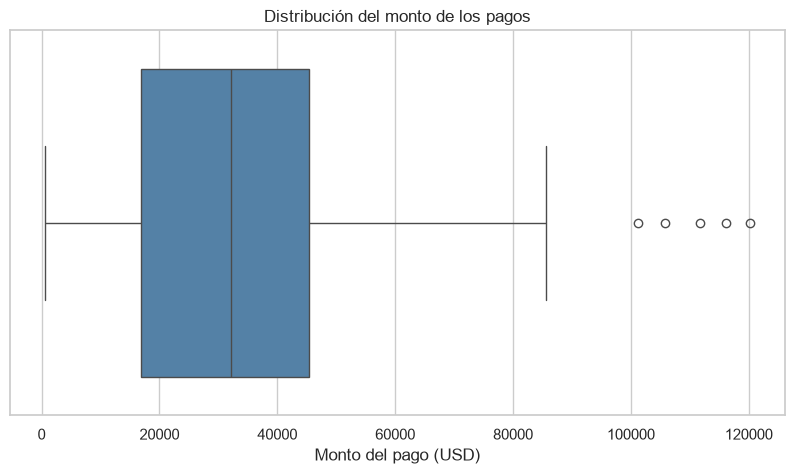

Límite de valores atípicos: 88016.42
Pagos atípicos: 5


count       273.000000
mean      32431.645531
std       20997.116917
min         615.450000
25%       16909.840000
50%       32077.440000
75%       45352.470000
max      120166.580000
Name: amount, dtype: float64

In [15]:
# Distribucion del monto de los pagos
sns.boxplot(x=payments["amount"], color="steelblue")
plt.title("Distribución del monto de los pagos")
plt.xlabel("Monto del pago (USD)")
plt.show()

# Contar pagos atipicos
q1 = payments["amount"].quantile(0.25)
q3 = payments["amount"].quantile(0.75)
limite = q3 + 1.5 * (q3 - q1)
atipicos = (payments["amount"] > limite).sum()
print("Límite de valores atípicos:", round(limite, 2))
print("Pagos atípicos:", atipicos)

payments["amount"].describe()

**Interpretación:** Los 273 pagos van de 615,45 a 120.166,58 USD. El promedio (32.432 USD) y la mediana (32.077 USD) son muy parecidos, por lo que el pago típico ronda los 32.000 USD. La caja del gráfico muestra que la mitad de los pagos está entre 16.910 y 45.352 USD. Los puntos sueltos a la derecha son 5 pagos atípicos (1,8 %), mayores a 88.016 USD, que se salen del comportamiento normal. Para el negocio, estos pagos grandes probablemente vienen de clientes importantes, por lo que conviene identificarlos y cuidar la relación con ellos, ya que aportan mucho dinero de una sola vez.